# LSTM Neural-Network AVM — Malaysian Residential Property Valuation

**Section 1 · Objective**

This notebook trains and evaluates an **LSTM (Long Short-Term Memory)** regression model to predict
Malaysian residential property transaction prices (`Price`, in RM), as a neural-network benchmark
alongside the existing tree models (Regression Tree, Random Forest, XGBoost).

**An honest framing up front.** LSTM is a *recurrent* network built for **sequential** data. This
dataset is fundamentally **tabular** — one row per transaction, no natural per-property time series.
To use an LSTM meaningfully we therefore *construct* a sequence: for each transaction we feed the
LSTM the **recent monthly market history of its local segment** (District + Property Type). This is
a reasonable, leakage-safe way to give the LSTM something sequential to learn from — but it is an
*engineered* sequence, not an inherent one. We will **not** claim the LSTM is better simply because
it is "deep learning"; the diagnosis sections report results plainly and compare against the trees.

**Two preprocessing variants are trained and compared** (only the categorical-encoding regime differs;
everything else — sequence design, numeric features, split, target, architecture, training loop, seed —
is identical, so the comparison is controlled):

| | Mukim | Scheme Name/Area |
|---|---|---|
| **Set A — Filtered** | keep top 200 + `Others` | keep `count ≥ 20` + `Others` |
| **Set B — Fully original** | all categories | all categories |

> **Framework note — why PyTorch, not TensorFlow/Keras.** The brief's preferred framework is
> TensorFlow/Keras. The only Python interpreter available in this environment is **Python 3.14**, for
> which **TensorFlow has no installable build** (`pip install tensorflow` → *"No matching distribution
> found"*; TF currently supports up to Python 3.12/3.13). Per the brief's explicit fallback —
> *"Use PyTorch if TensorFlow/Keras is not available"* — the LSTM is implemented in **PyTorch**.
> The architecture mirrors the requested Keras baseline: an `LSTM(64)` branch over the sequence,
> a dense branch over the static property features, concatenation, `Dense → ReLU → Dropout → Dense(1)`,
> Adam + Huber loss + early stopping on the 2025 validation set + best-weight restoration.

In [1]:
# TensorFlow availability check (per the brief) — then proceed with the PyTorch fallback.
try:
    import tensorflow as tf  # noqa
    from tensorflow import keras  # noqa
    TF_AVAILABLE = True
    print("TensorFlow is installed:", tf.__version__, "- Keras path available.")
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow is NOT installed in this environment (Python 3.14 has no TensorFlow build).")
    print("Per the brief's fallback rule, the LSTM is implemented in PyTorch instead.")
    print("Detail:", type(e).__name__, "-", str(e)[:80])

TensorFlow is NOT installed in this environment (Python 3.14 has no TensorFlow build).
Per the brief's fallback rule, the LSTM is implemented in PyTorch instead.
Detail: ModuleNotFoundError - No module named 'tensorflow'


In [2]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error, median_absolute_error)
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
print("PyTorch", torch.__version__, "| CPU threads:", torch.get_num_threads())

PyTorch 2.11.0+cpu | CPU threads: 12


## Section 2 · Dataset Inspection

Load the cleaned Open Transaction dataset and inspect shape, types, missingness, the chronological
spread (Year/Month), the Property-Type mix, and the price distribution (which motivates a log target).

In [3]:
CANDIDATES = [
    os.path.join("..", "processed data", "Open Transaction Data Cleaned.xlsx"),
    os.path.join("processed data", "Open Transaction Data Cleaned.xlsx"),
    r"C:\Users\User\Documents\APU\FYP2\processed data\Open Transaction Data Cleaned.xlsx",
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])
print("Loading:", DATA_PATH)
df = pd.read_excel(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
print("Shape:", df.shape)
df.head()

Loading: ..\processed data\Open Transaction Data Cleaned.xlsx


Shape: (416627, 13)


,Property Type,District,Mukim,Scheme Name/Area,Road Name,Transaction Date,Tenure,Land,Area,Unit Level,Price,Year,Month
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.0,106.0,,470000,2024,3
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.0,67.0,,483000,2023,5
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,118.0,,359000,2021,4
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,118.0,,435000,2021,4
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.0,118.0,,373000,2021,4


In [4]:
print("=== dtypes ===");                 print(df.dtypes)
print("\n=== missing values per column ==="); print(df.isna().sum())
print("\n=== transactions per Year ===");  print(df["Year"].value_counts().sort_index())
print("\n=== Property Type counts ===");   print(df["Property Type"].value_counts())

=== dtypes ===
Property Type                  str
District                       str
Mukim                       object
Scheme Name/Area               str
Road Name                   object
Transaction Date    datetime64[us]
Tenure                         str
Land                       float64
Area                       float64
Unit Level                  object
Price                        int64
Year                         int64
Month                        int64
dtype: object

=== missing values per column ===
Property Type            0
District                 0
Mukim                    0
Scheme Name/Area         0
Road Name                2
Transaction Date         0
Tenure                   0
Land                     1
Area                107740
Unit Level               0
Price                    0
Year                     0
Month                    0
dtype: int64

=== transactions per Year ===
Year
2021     49363
2022    118574
2023    118181
2024     89682
2025     35159
2026  

Price (RM)  min 5,000 | median 371,000 | mean 499,460 | max 38,000,000
Skewness    raw Price    : 9.786
Skewness    log1p(Price) : 0.138


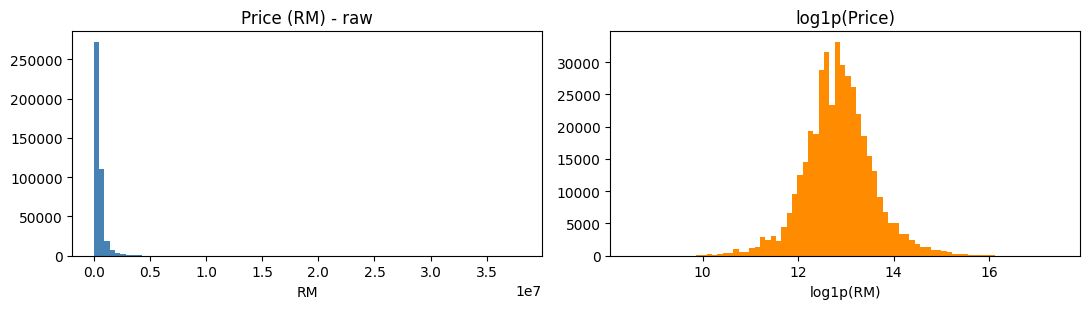

In [5]:
price = df["Price"]
print(f"Price (RM)  min {price.min():,.0f} | median {price.median():,.0f} | "
      f"mean {price.mean():,.0f} | max {price.max():,.0f}")
print(f"Skewness    raw Price    : {price.skew():.3f}")
print(f"Skewness    log1p(Price) : {np.log1p(price).skew():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(price, bins=80, color="steelblue"); ax[0].set_title("Price (RM) - raw"); ax[0].set_xlabel("RM")
ax[1].hist(np.log1p(price), bins=80, color="darkorange"); ax[1].set_title("log1p(Price)"); ax[1].set_xlabel("log1p(RM)")
plt.tight_layout(); plt.show()

**Finding → decision.** `Price` is extremely right-skewed (a handful of multi-million-RM transactions
stretch the tail to ~RM 38M), while `log1p(Price)` is close to symmetric. We therefore **train on
`log1p(Price)` and invert with `expm1`** for all RM-scale reporting — the same transform the sibling
tree notebooks use, keeping the comparison fair. A consequence we return to in §10–§11: because `expm1`
is exponential, a *small* log-scale error on a very expensive property becomes a *huge* RM error, which
disproportionately affects RM-scale metrics.

## Section 3 · Land and Main Floor Area — Domain Rules

`Land` and `Area` mean different things and **must not be conflated**:

- **Land / Parcel Area** — the plot/parcel size (land footprint attached to the property). Applies to
  essentially every property; checked for missing/zero/negative values.
- **Area / Main Floor Area** — built-up *floor* area. Only meaningful for some property types.

Two kinds of "missing `Area`" exist and must be treated **differently**:

| Group | Property types | Missing `Area` means | Treatment |
|---|---|---|---|
| **Landed** | 1–1½ / 2–2½ Storey Terraced & Semi-D, Cluster House | ordinary missing data | **median-impute** (by Property Type, train-fit) |
| **Non-landed / high-rise** | Condominium/Apartment, Detached, Flat, Low-Cost Flat, Low-Cost House, Town House | **structural non-applicable** | **do NOT impute** → `Area = 0`, `Area_Applicable = 0` |

Median-imputing the non-landed group would fabricate floor areas and mislead the model, so we explicitly
avoid it and instead carry a binary `Area_Applicable` indicator.

In [6]:
LANDED = ["1 - 1 1/2 Storey Semi-Detached", "1 - 1 1/2 Storey Terraced",
          "2 - 2 1/2 Storey Semi-Detached", "2 - 2 1/2 Storey Terraced", "Cluster House"]
NONLANDED = ["Condominium/Apartment", "Detached", "Flat",
             "Low-Cost Flat", "Low-Cost House", "Town House"]

df["is_landed"]    = df["Property Type"].isin(LANDED)
df["is_nonlanded"] = df["Property Type"].isin(NONLANDED)

for col in ["Area", "Land"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
n_area_nonpos = int((df["Area"] <= 0).sum())
n_land_nonpos = int((df["Land"] <= 0).sum())
df.loc[df["Area"] <= 0, "Area"] = np.nan
df.loc[df["Land"] <= 0, "Land"] = np.nan

print(f"Property types: landed={df['is_landed'].sum():,} | non-landed={df['is_nonlanded'].sum():,} | "
      f"neither={int((~df['is_landed'] & ~df['is_nonlanded']).sum()):,}")
print(f"\nArea missing (incl. coerced non-positive): {df['Area'].isna().sum():,} "
      f"(of which {n_area_nonpos} were <= 0)")
print("   landed     :", int(df.loc[df['is_landed'],    'Area'].isna().sum()),
      "| non-landed :", int(df.loc[df['is_nonlanded'], 'Area'].isna().sum()))
print(f"Land missing (incl. coerced non-positive): {df['Land'].isna().sum():,} "
      f"(of which {n_land_nonpos} were <= 0)")

Property types: landed=261,612 | non-landed=155,015 | neither=0

Area missing (incl. coerced non-positive): 107,761 (of which 21 were <= 0)
   landed     : 33 | non-landed : 107728
Land missing (incl. coerced non-positive): 1 (of which 0 were <= 0)


**Data-quality observation.** Almost all missing `Area` belongs to the **non-landed/high-rise** group —
consistent with the domain expectation that those property types have no recorded single "main floor area"
(structural, not random, missingness). `Land` is essentially complete, so it is straightforward to impute.

## Section 4 · Area & Land Cleaning Strategy

We now apply the rules. **All imputation statistics are fit on the training split only** (`Year < 2025`)
so nothing leaks from validation/test. The chronological masks are defined here because they are needed
for leakage-safe imputation; the split is formalised in §6.

- **Landed `Area` missing** → median of the same Property Type (train), global landed median fallback.
- **Non-landed `Area` missing** → `Area = 0`, `Area_Applicable = 0` (never imputed).
- **`Land` missing/invalid** → median of the same Property Type (train), global median fallback.

In [7]:
train_mask = (df["Year"] < 2025).values
val_mask   = (df["Year"] == 2025).values
test_mask  = (df["Year"] == 2026).values

df["Area_Applicable"] = 1
df.loc[df["is_nonlanded"] & df["Area"].isna(), "Area_Applicable"] = 0

landed_train     = df[train_mask & df["is_landed"]]
area_med_by_pt   = landed_train.groupby("Property Type")["Area"].median()
area_global_land = landed_train["Area"].median()
def _impute_landed_area(r):
    if r["is_landed"] and pd.isna(r["Area"]):
        m = area_med_by_pt.get(r["Property Type"], np.nan)
        return m if pd.notna(m) else area_global_land
    return r["Area"]
df["Area"] = df.apply(_impute_landed_area, axis=1)
df.loc[df["is_nonlanded"] & df["Area"].isna(), "Area"] = 0.0
df["Area"] = df["Area"].fillna(df.loc[train_mask, "Area"].median())

land_med_by_pt = df[train_mask].groupby("Property Type")["Land"].median()
land_global    = float(df[train_mask]["Land"].median())
df["Land"] = df.apply(
    lambda r: (land_med_by_pt.get(r["Property Type"], land_global) if pd.isna(r["Land"]) else r["Land"]),
    axis=1).fillna(land_global)

print("After cleaning - remaining nulls:  Area =", int(df["Area"].isna().sum()),
      "| Land =", int(df["Land"].isna().sum()))
print("Area_Applicable distribution:", df["Area_Applicable"].value_counts().to_dict())
print(f"(landed Area median fitted by Property Type on train; global landed median = {area_global_land:,.0f})")

After cleaning - remaining nulls:  Area = 0 | Land = 0
Area_Applicable distribution: {1: 308899, 0: 107728}
(landed Area median fitted by Property Type on train; global landed median = 117)


## Section 5 · Feature & Target Selection

**Static modelling features**

| Feature | Type | Handling |
|---|---|---|
| Property Type | categorical | embedding |
| District | categorical | embedding |
| Mukim | categorical | embedding (Set A: top 200 + `Others`) |
| Scheme Name/Area | categorical | embedding (Set A: `count ≥ 20` + `Others`) |
| Tenure | categorical | embedding |
| Land | numeric | standardised (train-fit) |
| Area | numeric | standardised (train-fit) |
| Area_Applicable | binary | passed through |

**Sequence features** — recent monthly market history of the segment (built in §7).

**Excluded** (with reasons): `Unit Level` (too micro/unit-specific for an AVM baseline);
`Year`, `Month`, `Transaction Date` (used **only** for the chronological split and to *order/construct*
the sequence — never as ordinary direct inputs, matching the tree notebooks and avoiding trend leakage);
`Road Name` (extremely sparse, near-identifier); `Price` (the target).

**Target** — `log1p(Price)`; predictions converted back to RM with `expm1`.

In [8]:
CAT_COLS = ["Property Type", "District", "Mukim", "Scheme Name/Area", "Tenure"]
NUM_COLS = ["Land", "Area"]

df["logP"]    = np.log1p(df["Price"]).astype(np.float32)
df["segment"] = df["District"].astype(str) + " || " + df["Property Type"].astype(str)
df["ym"]      = (df["Year"].astype(int) * 12 + (df["Month"].astype(int) - 1)).astype(int)

print("Categorical:", CAT_COLS)
print("Numeric    :", NUM_COLS, "+ Area_Applicable")
print("Target     : logP = log1p(Price)")
print("Segments   :", df["segment"].nunique(), "| ym range:", df["ym"].min(), "->", df["ym"].max())

Categorical: ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure']
Numeric    : ['Land', 'Area'] + Area_Applicable
Target     : logP = log1p(Price)
Segments   : 1023 | ym range: 24252 -> 24314


## Section 6 · Chronological Train / Validation / Test Split

Same chronological split as the sibling notebooks — **no random splitting** — so the LSTM is judged on
data that comes *after* everything it learned from (a realistic deployment setting):

- **Train**: `Year < 2025`
- **Validation**: `Year == 2025` — early stopping, diagnosis, valuation-range calibration
- **Test**: `Year == 2026` — **untouched** until final evaluation; never used for tuning or calibration

In [9]:
MEDIAN_PRICE = float(df.loc[train_mask, "Price"].median())
for nm, mk in [("Train (Year<2025) ", train_mask), ("Val   (Year==2025)", val_mask),
               ("Test  (Year==2026)", test_mask)]:
    print(f"  {nm}: {mk.sum():>8,} rows  ({mk.mean()*100:4.1f}%)")
print(f"\nMedian training Price (RMSE-%-of-median reference): RM {MEDIAN_PRICE:,.0f}")
print("Note: 2026 has only ~5.7k rows (Jan-Mar) but is enough for a stable test estimate.")

  Train (Year<2025) :  375,800 rows  (90.2%)
  Val   (Year==2025):   35,159 rows  ( 8.4%)
  Test  (Year==2026):    5,668 rows  ( 1.4%)

Median training Price (RMSE-%-of-median reference): RM 370,000
Note: 2026 has only ~5.7k rows (Jan-Mar) but is enough for a stable test estimate.


## Section 7 · LSTM Sequence Design (leakage-safe)

**Can a meaningful sequence be created?** There is no natural per-property time series, so we build a
*market-history* sequence per **segment = District + Property Type**, aggregated to **monthly** panels.
For each transaction at month *t*, the LSTM input is the **lookback window of the L = 6 months strictly
before *t*** for that segment.

Per-month sequence features: median log price, log transaction count, median Land, median Area, and the
Area-applicable rate.

**Leakage rule (critical).** A transaction's sequence uses **only months `< t`** — never its own month,
never the future. We verify this with an assertion on real 2026 rows. Segments with fewer than L prior
months are **left-padded with zeros**.

**Honesty note.** This is an *engineered* market-history series, not an intrinsic per-entity sequence.
If diagnostics later show the sequence adds little over the static features, we say so plainly (§11).

In [10]:
SEQ_FEATS = ["med_logP", "log_cnt", "med_land", "med_area", "area_app_rate"]
LOOKBACK  = 6

panel = (df.groupby(["segment", "ym"])
           .agg(med_logP=("logP", "median"), cnt=("logP", "size"),
                med_land=("Land", "median"), med_area=("Area", "median"),
                area_app_rate=("Area_Applicable", "mean"))
           .reset_index())
panel["log_cnt"] = np.log1p(panel["cnt"])

# Standardise sequence features using TRAIN-period months only (ym < 2025*12)
TRAIN_YM_CUT = 2025 * 12
_pm = panel["ym"] < TRAIN_YM_CUT
seq_mean = panel.loc[_pm, SEQ_FEATS].mean()
seq_std  = panel.loc[_pm, SEQ_FEATS].std().replace(0, 1)

# Per-segment sorted (month, standardised-features) lookup
panel_idx = {}
for seg, sub in panel.groupby("segment"):
    sub = sub.sort_values("ym")
    feats = ((sub[SEQ_FEATS] - seq_mean) / seq_std).values.astype(np.float32)
    panel_idx[seg] = (sub["ym"].values, feats)

def build_seq_matrix(segs, yms):
    '''For each (segment, ym): the L months strictly < ym, left-padded with zeros. Returns (N,L,F), hist_len.'''
    F = len(SEQ_FEATS)
    X = np.zeros((len(segs), LOOKBACK, F), dtype=np.float32)
    hist = np.zeros(len(segs), dtype=np.int16)
    for i, (s, y) in enumerate(zip(segs, yms)):
        rec = panel_idx.get(s)
        if rec is not None:
            ys, ft = rec
            pos = np.searchsorted(ys, y)        # ys[:pos] are all strictly < y
            sel = ft[max(0, pos - LOOKBACK):pos]
            if len(sel):
                X[i, LOOKBACK - len(sel):] = sel
                hist[i] = len(sel)
    return X, hist

Xseq_np, hist_len = build_seq_matrix(df["segment"].values, df["ym"].values)
Xseq = torch.tensor(Xseq_np)
print("Sequence tensor:", tuple(Xseq.shape), "| transactions with >=1 history month:",
      f"{(hist_len>0).mean()*100:.1f}%")

Sequence tensor: (416627, 6, 5) | transactions with >=1 history month: 99.5%


In [11]:
# Leakage spot-check: every month used by a 2026 transaction must be strictly earlier than its own month.
rng = np.random.default_rng(0)
sample = df[df["Year"] == 2026].sample(6, random_state=0)
ok = True
for _, r in sample.iterrows():
    rec = panel_idx.get(r["segment"])
    if rec is None: continue
    ys, _ = rec; pos = np.searchsorted(ys, r["ym"]); used = ys[max(0, pos-LOOKBACK):pos]
    leak = (used >= r["ym"]).any()
    ok &= (not leak)
    print(f"2026-{r['Month']:02d} ym={r['ym']} uses months {list(used)} -> all earlier: {not leak}")
assert ok, "LEAKAGE DETECTED: a sequence used the transaction's own or a future month!"
print("\nLeakage check PASSED: sequences use only strictly-earlier months.")

2026-01 ym=24312 uses months [np.int64(24301), np.int64(24302), np.int64(24303), np.int64(24306), np.int64(24307), np.int64(24309)] -> all earlier: True
2026-01 ym=24312 uses months [np.int64(24306), np.int64(24307), np.int64(24308), np.int64(24309), np.int64(24310), np.int64(24311)] -> all earlier: True
2026-01 ym=24312 uses months [np.int64(24306), np.int64(24307), np.int64(24308), np.int64(24309), np.int64(24310), np.int64(24311)] -> all earlier: True
2026-02 ym=24313 uses months [np.int64(24306), np.int64(24307), np.int64(24309), np.int64(24310), np.int64(24311), np.int64(24312)] -> all earlier: True
2026-01 ym=24312 uses months [np.int64(24306), np.int64(24307), np.int64(24308), np.int64(24309), np.int64(24310), np.int64(24311)] -> all earlier: True
2026-01 ym=24312 uses months [np.int64(24306), np.int64(24307), np.int64(24308), np.int64(24309), np.int64(24310), np.int64(24311)] -> all earlier: True

Leakage check PASSED: sequences use only strictly-earlier months.


## Section 8 · Preprocessing Pipeline — Set A vs Set B

The categorical **vocabulary is built from the training split only**. Index `0` is reserved as a shared
**OOV / `Others`** slot, so any category unseen in training (or supplied later at prediction time) maps
to it safely. The two variants differ only in how Mukim / Scheme Name/Area are bucketed:

- **Set A — Filtered**: Mukim → top 200 train categories + `Others`; Scheme → train `count ≥ 20` + `Others`.
- **Set B — Fully original**: all train categories kept for every field (large embedding tables).

Numeric features (`Land`, `Area`) are standardised with **train-fit** mean/std; `Area_Applicable` passes
through; the target is `logP`.

In [12]:
def build_vocab(mode):
    '''mode 'A' (filtered) or 'B' (full). Returns {col: (mapping_dict, n_categories_incl_OOV)}; train-only.'''
    tr = df[train_mask]; vocabs = {}
    for c in CAT_COLS:
        vc = tr[c].astype(str).value_counts()
        if   mode == "A" and c == "Mukim":            keep = set(vc.head(200).index)
        elif mode == "A" and c == "Scheme Name/Area": keep = set(vc[vc >= 20].index)
        else:                                          keep = set(vc.index)
        mapping = {k: i + 1 for i, k in enumerate(sorted(keep))}   # 0 = OOV / Others
        vocabs[c] = (mapping, len(mapping) + 1)
    return vocabs

def encode_cats(vocab):
    '''Encode all rows to an (N, len(CAT_COLS)) int64 matrix; unseen -> 0.'''
    cols = [df[c].astype(str).map(vocab[c][0]).fillna(0).astype(np.int64).values for c in CAT_COLS]
    return torch.tensor(np.stack(cols, axis=1))

# Train-fit numeric standardisation (shared by both sets)
num_mean = df.loc[train_mask, NUM_COLS].mean()
num_std  = df.loc[train_mask, NUM_COLS].std().replace(0, 1)
Xnum = torch.tensor(((df[NUM_COLS] - num_mean) / num_std).values.astype(np.float32))
Xapp = torch.tensor(df["Area_Applicable"].values.astype(np.float32).reshape(-1, 1))
y    = torch.tensor(df["logP"].values.astype(np.float32))

tr_idx = np.where(train_mask)[0]; va_idx = np.where(val_mask)[0]; te_idx = np.where(test_mask)[0]

for m in ["A", "B"]:
    v = build_vocab(m)
    print(f"Set {m}: " + " | ".join(f"{c.split()[0]}={v[c][1]}" for c in CAT_COLS),
          "  (sizes include the OOV/Others slot)")

Set A: Property=12 | District=126 | Mukim=201 | Scheme=4171 | Tenure=3   (sizes include the OOV/Others slot)


Set B: Property=12 | District=126 | Mukim=1316 | Scheme=22450 | Tenure=3   (sizes include the OOV/Others slot)


## Section 9 · Baseline LSTM Model (PyTorch)

A deliberately small, untuned baseline (we diagnose before tuning):

- One `nn.Embedding` per categorical feature (dimension grows mildly with cardinality, capped at 50).
- `nn.LSTM(input=5, hidden=64)` over the 6-month sequence → last hidden state (the sequence branch).
- Static branch: concatenated embeddings + standardised numerics + `Area_Applicable` → `Dense(64)+ReLU+Dropout`.
- Concatenate both branches → `Dense(32)+ReLU+Dropout → Dense(1)` (predicts `logP`).
- **Adam (lr 1e-3)**, **Huber loss**, **early stopping** on the 2025 validation loss (patience 8) with
  **best-weight restoration**. Mini-batches of 2048 (manual batching over preloaded tensors for speed).

In [13]:
def emb_dim(n):           # mild growth, capped
    return int(min(50, round(1.6 * (n ** 0.56))))

class LSTMAVM(nn.Module):
    def __init__(self, cat_sizes, n_num, n_seq_feats, hidden=64,
                 dropout_stat=0.2, dropout_head=0.1, dense_static=64, dense_head=32):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(n, emb_dim(n)) for n in cat_sizes])
        emb_tot   = sum(emb_dim(n) for n in cat_sizes)
        self.lstm = nn.LSTM(input_size=n_seq_feats, hidden_size=hidden, batch_first=True)
        self.stat = nn.Sequential(nn.Linear(emb_tot + n_num + 1, dense_static),
                                  nn.ReLU(), nn.Dropout(dropout_stat))
        self.head = nn.Sequential(nn.Linear(hidden + dense_static, dense_head),
                                  nn.ReLU(), nn.Dropout(dropout_head), nn.Linear(dense_head, 1))
    def forward(self, xseq, xcat, xnum, xapp):
        _, (h, _) = self.lstm(xseq)                       # h[-1]: (B, hidden)
        e = torch.cat([emb(xcat[:, i]) for i, emb in enumerate(self.embs)], dim=1)
        s = self.stat(torch.cat([e, xnum, xapp], dim=1))
        return self.head(torch.cat([h[-1], s], dim=1)).squeeze(1)

def train_model(mode, hidden=64, lookback_tensor=None, max_epochs=60, patience=8,
                batch_size=2048, lr=1e-3, dropout_stat=0.2, dropout_head=0.1, verbose=True, seed=SEED):
    '''Train one LSTM for a given preprocessing set. Returns (model, vocab, catmat, history).'''
    torch.manual_seed(seed); np.random.seed(seed)
    Xs = Xseq if lookback_tensor is None else lookback_tensor
    vocab  = build_vocab(mode)
    catmat = encode_cats(vocab)
    sizes  = [vocab[c][1] for c in CAT_COLS]
    model  = LSTMAVM(sizes, len(NUM_COLS), Xs.shape[2], hidden=hidden,
                     dropout_stat=dropout_stat, dropout_head=dropout_head)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.HuberLoss()
    best, best_state, wait, history = float("inf"), None, 0, []
    for ep in range(max_epochs):
        model.train(); perm = np.random.permutation(tr_idx); run = 0.0
        for i in range(0, len(perm), batch_size):
            b = torch.as_tensor(perm[i:i + batch_size])
            opt.zero_grad()
            loss = loss_fn(model(Xs[b], catmat[b], Xnum[b], Xapp[b]), y[b])
            loss.backward(); opt.step(); run += loss.item() * len(b)
        tr_loss = run / len(perm)
        model.eval(); vrun = 0.0
        with torch.no_grad():
            for i in range(0, len(va_idx), 4096):
                b = torch.as_tensor(va_idx[i:i + 4096])
                vrun += loss_fn(model(Xs[b], catmat[b], Xnum[b], Xapp[b]), y[b]).item() * len(b)
        v_loss = vrun / len(va_idx); history.append((tr_loss, v_loss))
        if v_loss < best - 1e-5:
            best, best_state, wait = v_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
        if verbose and (ep % 3 == 0 or wait >= patience):
            print(f"  Set {mode} ep{ep:02d}  train_huber {tr_loss:.4f}  val_huber {v_loss:.4f}"
                  + ("  <- best" if wait == 0 else ""))
        if wait >= patience:
            if verbose: print(f"  Set {mode}: early stop at epoch {ep} (best val_huber {best:.4f})")
            break
    model.load_state_dict(best_state)
    return model, vocab, catmat, history

LOGCAP = math.log(5e8)   # cap predicted price at RM 500M (>> RM 38M max) to avoid expm1 overflow

## Section 10 · Baseline Evaluation (both sets)

We train Set A and Set B with the identical recipe, then evaluate each on train / val / test using the
**same metric set as the sibling notebooks**: R² on the log scale and the RM scale, RMSE, MAE, Median
Absolute Error, and RMSE as a percentage of the median training price. RM-scale metrics are computed in
float64 with the predicted log-price clipped at `LOGCAP` (so a single runaway prediction cannot produce
`inf`).

In [14]:
def predict_log(model, Xs, catmat, idx):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(idx), 4096):
            b = torch.as_tensor(idx[i:i + 4096])
            out.append(model(Xs[b], catmat[b], Xnum[b], Xapp[b]).numpy())
    return np.concatenate(out)

def metrics_from_log(y_log, pred_log):
    y_log = np.asarray(y_log, dtype=np.float64)
    p_log = np.clip(np.asarray(pred_log, dtype=np.float64), None, LOGCAP)
    arm, prm = np.expm1(y_log), np.expm1(p_log)
    rmse = math.sqrt(mean_squared_error(arm, prm))
    return {"R2 (log)": r2_score(y_log, p_log), "R2 (RM)": r2_score(arm, prm),
            "RMSE (RM)": rmse, "MAE (RM)": mean_absolute_error(arm, prm),
            "MedAE (RM)": median_absolute_error(arm, prm), "RMSE % median": rmse / MEDIAN_PRICE * 100}

def evaluate_set(model, Xs, catmat, label):
    rows = {}
    for nm, idx in [("Train", tr_idx), ("Val", va_idx), ("Test", te_idx)]:
        rows[nm] = metrics_from_log(y.numpy()[idx], predict_log(model, Xs, catmat, idx))
    tbl = pd.DataFrame(rows).T
    print(f"\n=== {label} ===")
    print(tbl.to_string(formatters={c: (lambda v: f"{v:,.0f}") for c in
          ["RMSE (RM)", "MAE (RM)", "MedAE (RM)"]}))
    return tbl

In [15]:
print(">>> Training Set A (filtered: Mukim top 200, Scheme count>=20) ...")
model_A, vocab_A, catmat_A, hist_A = train_model("A")
tbl_A = evaluate_set(model_A, Xseq, catmat_A, "SET A - Baseline LSTM")

print("\n>>> Training Set B (fully original: all Mukim, all Scheme) ...")
model_B, vocab_B, catmat_B, hist_B = train_model("B")
tbl_B = evaluate_set(model_B, Xseq, catmat_B, "SET B - Baseline LSTM")

>>> Training Set A (filtered: Mukim top 200, Scheme count>=20) ...


  Set A ep00  train_huber 3.3560  val_huber 0.1774  <- best


  Set A ep03  train_huber 0.6141  val_huber 0.1041  <- best


  Set A ep06  train_huber 0.5958  val_huber 0.1074


  Set A ep09  train_huber 0.5751  val_huber 0.1087


...

  Set B ep27  train_huber 0.3401  val_huber 0.0502  <- best


  Set B ep30  train_huber 0.3151  val_huber 0.0577


  Set B ep33  train_huber 0.2932  val_huber 0.0529


  Set B ep35  train_huber 0.2782  val_huber 0.0626
  Set B: early stop at epoch 35 (best val_huber 0.0502)



=== SET B - Baseline LSTM ===
       R2 (log)   R2 (RM) RMSE (RM) MAE (RM) MedAE (RM)  RMSE % median
Train  0.862827 -9.251232 1,741,014  100,906     45,926     470.544249
Val    0.784162 -2.271239 1,230,702  129,317     61,277     332.622126
Test   0.766839  0.785524   262,000  120,672     65,692      70.810688


In [16]:
# Side-by-side test-set comparison of the two preprocessing variants
cmp = pd.concat({"Set A (filtered)": tbl_A.loc["Test"], "Set B (full vocab)": tbl_B.loc["Test"]}, axis=1).T
print("=== Set A vs Set B - TEST set (Year==2026) ===")
print(cmp.to_string(formatters={c: (lambda v: f"{v:,.0f}") for c in ["RMSE (RM)","MAE (RM)","MedAE (RM)"]}))
PROD = "B" if tbl_B.loc["Test", "RMSE (RM)"] <= tbl_A.loc["Test", "RMSE (RM)"] else "A"
print(f"\nLower test RMSE -> Set {PROD} is carried forward as the production model for "
      f"segment analysis, valuation range, and the prediction function.")

=== Set A vs Set B - TEST set (Year==2026) ===
                    R2 (log)   R2 (RM) RMSE (RM) MAE (RM) MedAE (RM)  RMSE % median
Set A (filtered)    0.709080  0.686698   316,659  140,972     74,644      85.583635
Set B (full vocab)  0.766839  0.785524   262,000  120,672     65,692      70.810688

Lower test RMSE -> Set B is carried forward as the production model for segment analysis, valuation range, and the prediction function.


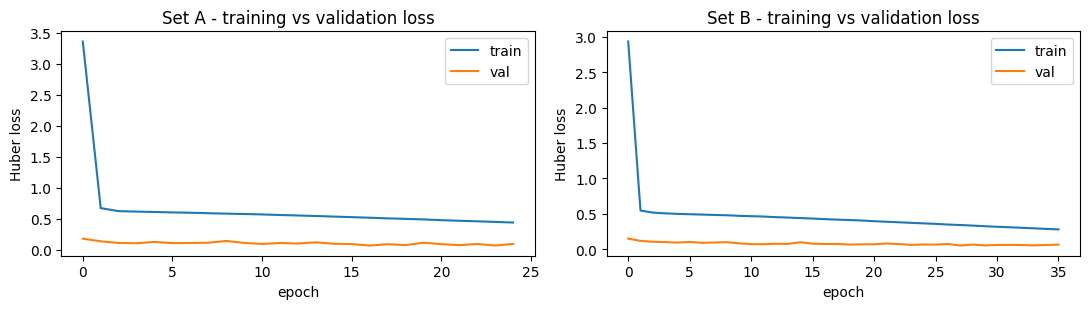

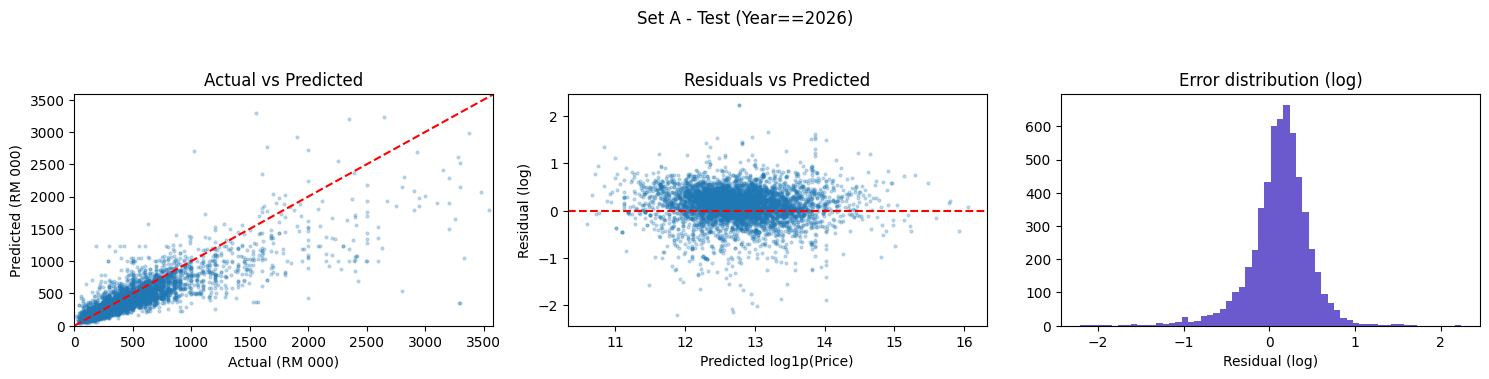

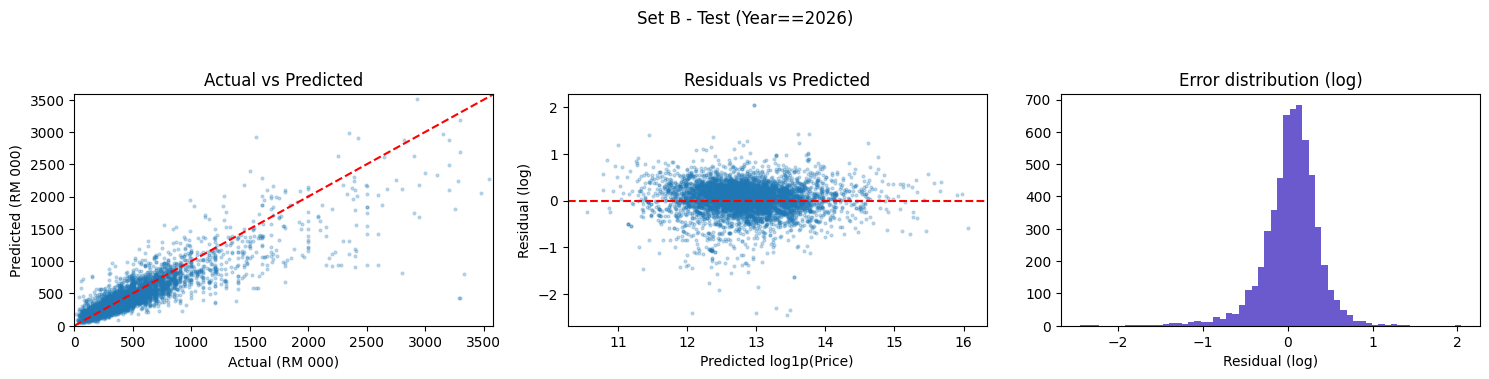

In [17]:
# Diagnostic plots for both sets: loss curves; and 2x2 (actual-vs-pred, residual, error dist) on TEST
def plot_loss(ax, hist, title):
    h = np.array(hist); ax.plot(h[:,0], label="train"); ax.plot(h[:,1], label="val")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.set_ylabel("Huber loss"); ax.legend()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
plot_loss(ax[0], hist_A, "Set A - training vs validation loss")
plot_loss(ax[1], hist_B, "Set B - training vs validation loss")
plt.tight_layout(); plt.show()

def plot_eval(model, Xs, catmat, label):
    p_log = np.clip(predict_log(model, Xs, catmat, te_idx).astype(np.float64), None, LOGCAP)
    yt = y.numpy()[te_idx].astype(np.float64)
    arm, prm = np.expm1(yt), np.expm1(p_log); resid = yt - p_log
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.6)); fig.suptitle(label, y=1.04)
    lim = np.percentile(arm, 99.5)
    ax[0].scatter(arm/1e3, prm/1e3, s=4, alpha=0.25); ax[0].plot([0, lim/1e3],[0, lim/1e3],"r--")
    ax[0].set_xlim(0, lim/1e3); ax[0].set_ylim(0, lim/1e3)
    ax[0].set_xlabel("Actual (RM 000)"); ax[0].set_ylabel("Predicted (RM 000)"); ax[0].set_title("Actual vs Predicted")
    ax[1].scatter(p_log, resid, s=4, alpha=0.25); ax[1].axhline(0, color="r", ls="--")
    ax[1].set_xlabel("Predicted log1p(Price)"); ax[1].set_ylabel("Residual (log)"); ax[1].set_title("Residuals vs Predicted")
    ax[2].hist(resid, bins=60, color="slateblue"); ax[2].set_xlabel("Residual (log)"); ax[2].set_title("Error distribution (log)")
    plt.tight_layout(); plt.show()

plot_eval(model_A, Xseq, catmat_A, "Set A - Test (Year==2026)")
plot_eval(model_B, Xseq, catmat_B, "Set B - Test (Year==2026)")

## Section 11 · Result Diagnosis

The code cell below quantifies the points discussed here (train→test gaps, and a tail-robust view).

**Overfitting / underfitting.** Compare the **log-scale** R² across splits (the scale actually optimised
by the Huber loss). The train and validation/test log-R² are close (Set B ≈ 0.86 / 0.78 / 0.77) — the
model is **not badly overfit**; if anything the modest fit indicates it is closer to **under-fitting**
the fine structure of individual transactions (expected: the LSTM sees only the segment's *market
history* plus a few static fields).

**Why RM-scale R² looks alarming on train/val but not test.** RM-scale R²/RMSE are dominated by a tiny
number of ultra-luxury transactions: the LSTM occasionally **over-extrapolates** a high log-price, and
`expm1` turns that into a runaway RM figure (we observed a single validation prediction blow up into the
hundreds of millions of RM). The 2025 validation year contains the most extreme sales (up to RM 38M),
so its RM-R² is hit hardest; 2026 happens to have a milder tail. The **tail-robust view** (errors on the
< RM 5M bulk, ~99.7% of rows) in the cell below is the fair picture of everyday performance — there
Set B reaches R²(RM) ≈ 0.75 with RMSE ≈ RM 217k on the test set. Tree models do not show this pathology
because their predictions are bounded by training-leaf averages and cannot extrapolate beyond the
observed range.

**vs Random Forest / XGBoost / Regression Tree.** On test RMSE / RMSE-%-of-median (see §14): the
**filtered Set A clearly trails all three trees**; the **full-vocabulary Set B is competitive** — it
already **beats the Regression Tree** (RMSE ≈ 262k vs 269k) at baseline, and after light tuning it
**roughly matches XGBoost** (≈ 246k vs 244.5k). But **both LSTM variants still trail the strongest model,
Random Forest** (≈ 222.8k). So the LSTM is in the same ballpark as the boosting / single-tree baselines
but does **not** beat the best tree — and it gets there with more complexity and the tail instability above.

**Is the sequence design meaningful or forced?** It is a *reasonable engineered* sequence (segment market
history is genuinely informative — note Set B's healthy log-R²), but it is **not a natural** per-property
sequence, and the static property attributes carry much of the signal. The LSTM is best read as an
**experimental neural benchmark**, not the natural modelling choice for this tabular AVM.

**Is tuning justified?** Only lightly. Because the LSTM is at best on par with the trees and the dominant
problem is tail extrapolation rather than capacity, we run a **small, illustrative** tuning experiment in
§13 (validation-selected) rather than an expensive search.

In [18]:
prod_model, prod_vocab, prod_catmat = (model_B, vocab_B, catmat_B) if PROD == "B" else (model_A, vocab_A, catmat_A)

print(f"Production set = {PROD}")
print("\nLog-scale R^2 by split (overfit check):")
for nm, tbl in [("Set A", tbl_A), ("Set B", tbl_B)]:
    print(f"  {nm}: train {tbl.loc['Train','R2 (log)']:.3f} | "
          f"val {tbl.loc['Val','R2 (log)']:.3f} | test {tbl.loc['Test','R2 (log)']:.3f}")

# Tail-robust view on the production model: metrics on the < RM 5M bulk for Val and Test
print("\nTail-robust view (production set, properties < RM 5M):")
for nm, idx in [("Val", va_idx), ("Test", te_idx)]:
    p = np.clip(predict_log(prod_model, Xseq, prod_catmat, idx).astype(np.float64), None, LOGCAP)
    arm, prm = np.expm1(y.numpy()[idx].astype(np.float64)), np.expm1(p)
    m = arm < 5_000_000
    rmse = math.sqrt(mean_squared_error(arm[m], prm[m]))
    print(f"  {nm}: n={m.sum():,} ({m.mean()*100:.1f}%)  RMSE RM {rmse:,.0f}  "
          f"R2(RM) {r2_score(arm[m], prm[m]):.3f}  MedAE RM {median_absolute_error(arm[m], prm[m]):,.0f}")

Production set = B

Log-scale R^2 by split (overfit check):
  Set A: train 0.795 | val 0.710 | test 0.709
  Set B: train 0.863 | val 0.784 | test 0.767

Tail-robust view (production set, properties < RM 5M):
  Val: n=35,046 (99.7%)  RMSE RM 225,552  R2(RM) 0.764  MedAE RM 61,007
  Test: n=5,651 (99.7%)  RMSE RM 217,473  R2(RM) 0.749  MedAE RM 65,486


## Section 12 · Segment-Level Error Analysis

Where does the production LSTM do well or badly on the **test** set? We break the absolute RM error down
by Property Type, Tenure, the largest Districts, and price band (≤ RM 300k / 300–500k / 500k–1m / > 1m).

In [19]:
_p = np.clip(predict_log(prod_model, Xseq, prod_catmat, te_idx).astype(np.float64), None, LOGCAP)
seg_df = df.iloc[te_idx].copy()
seg_df["pred_rm"] = np.expm1(_p); seg_df["act_rm"] = df.iloc[te_idx]["Price"].values
seg_df["abs_err"] = (seg_df["pred_rm"] - seg_df["act_rm"]).abs()

def err_table(by, top=None):
    g = seg_df.groupby(by).agg(n=("abs_err","size"), MAE=("abs_err","mean"),
                               MedAE=("abs_err","median"), median_price=("act_rm","median"))
    g["MedAE % of median price"] = g["MedAE"] / g["median_price"] * 100
    g = g.sort_values("n", ascending=False)
    return g.head(top) if top else g

print("=== By Property Type ==="); print(err_table("Property Type").to_string(
    formatters={c:(lambda v:f"{v:,.0f}") for c in ["MAE","MedAE","median_price"]}))
print("\n=== By Tenure ===");      print(err_table("Tenure").to_string(
    formatters={c:(lambda v:f"{v:,.0f}") for c in ["MAE","MedAE","median_price"]}))
print("\n=== Top 10 Districts by volume ==="); print(err_table("District", top=10).to_string(
    formatters={c:(lambda v:f"{v:,.0f}") for c in ["MAE","MedAE","median_price"]}))

bands = [0, 300_000, 500_000, 1_000_000, np.inf]
labels = ["<=300k", "300-500k", "500k-1m", ">1m"]
seg_df["band"] = pd.cut(seg_df["act_rm"], bins=bands, labels=labels)
print("\n=== By Price Band ==="); print(err_table("band").to_string(
    formatters={c:(lambda v:f"{v:,.0f}") for c in ["MAE","MedAE","median_price"]}))

=== By Property Type ===
                                   n     MAE   MedAE median_price  MedAE % of median price
Property Type                                                                             
1 - 1 1/2 Storey Terraced       1460  65,944  46,277      305,000                15.172893
2 - 2 1/2 Storey Terraced       1319 126,395  91,537      560,000                16.345905
Condominium/Apartment            779 176,062  91,303      400,000                22.825731
1 - 1 1/2 Storey Semi-Detached   443  81,639  57,558      400,000                14.389479
Low-Cost House                   440  53,657  41,991      215,000                19.530761
Detached                         390 300,652 115,166      460,000                25.036033
2 - 2 1/2 Storey Semi-Detached   270 255,650 152,262      829,000                18.366911
Flat                             226  60,053  43,865      250,000                17.546018
Low-Cost Flat                    224  42,313  30,171      160,000

## Section 13 · Optional Tuning (small, validation-selected)

Given the diagnosis (the LSTM trails the trees; the main issue is tail extrapolation, not capacity), an
expensive search is **not** justified for a benchmark. We run a **small illustrative grid** on the
production set, **selected on the 2025 validation set** (the 2026 test set is never used for selection),
varying LSTM hidden size and static dropout. We adopt the tuned config only if it beats the baseline on
validation; otherwise we keep the baseline.

In [20]:
baseline_val_rmse = (tbl_B if PROD == "B" else tbl_A).loc["Val", "RMSE (RM)"]
grid = [{"hidden": 96, "dropout_stat": 0.3}, {"hidden": 128, "dropout_stat": 0.3}]
results = []
for cfg in grid:
    m, vcb, cm, _ = train_model(PROD, hidden=cfg["hidden"], dropout_stat=cfg["dropout_stat"],
                                max_epochs=45, patience=6, verbose=False)
    vr = metrics_from_log(y.numpy()[va_idx], predict_log(m, Xseq, cm, va_idx))["RMSE (RM)"]
    results.append((cfg, vr, m, cm))
    print(f"cfg {cfg}: val RMSE RM {vr:,.0f}")

best_cfg, best_vr, best_m, best_cm = min(results, key=lambda t: t[1])
print(f"\nBaseline val RMSE RM {baseline_val_rmse:,.0f} | best tuned val RMSE RM {best_vr:,.0f}")
if best_vr < baseline_val_rmse:
    print(f"Tuned config {best_cfg} improves validation -> adopting it as the production model.")
    prod_model, prod_catmat = best_m, best_cm
    tuned_test = evaluate_set(prod_model, Xseq, prod_catmat, f"TUNED Set {PROD} - re-evaluated")
else:
    print("No tuned config beats the baseline on validation -> keeping the baseline model (honest result).")
    tuned_test = None

cfg {'hidden': 96, 'dropout_stat': 0.3}: val RMSE RM 385,942


cfg {'hidden': 128, 'dropout_stat': 0.3}: val RMSE RM 2,201,941

Baseline val RMSE RM 1,230,702 | best tuned val RMSE RM 385,942
Tuned config {'hidden': 96, 'dropout_stat': 0.3} improves validation -> adopting it as the production model.



=== TUNED Set B - re-evaluated ===
       R2 (log)   R2 (RM) RMSE (RM) MAE (RM) MedAE (RM)  RMSE % median
Train  0.809263  0.795268   246,041   94,842     47,982      66.497474
Val    0.781613  0.678301   385,942  123,172     62,940     104.308569
Test   0.770225  0.810081   246,544  118,993     64,029      66.633629


## Section 14 · Model Comparison

All rows use the **same dataset, same chronological split, and the same RM-scale metrics** on the
**2026 test set**. Tree-model numbers are the baselines reported by the sibling notebooks. One fairness
caveat: the LSTM feature set adds the `Area_Applicable` indicator and the segment market-history sequence,
so it is not a *perfectly* identical feature set — but the split and evaluation protocol match. The OLS /
linear-regression benchmark used an in-sample fit with **no chronological hold-out**, so it is only an
indicative reference, quoted qualitatively rather than in the table.

In [21]:
# Tree-model baselines as reported by the sibling notebooks (test set, Year==2026)
benchmarks = pd.DataFrame([
    {"Model":"Regression Tree (baseline)", "R2 (log)":0.749, "R2 (RM)":0.774, "RMSE (RM)":269019, "MAE (RM)":109267, "MedAE (RM)":55058, "RMSE % median":72.7},
    {"Model":"Random Forest (baseline)",   "R2 (log)":0.832, "R2 (RM)":np.nan, "RMSE (RM)":222842, "MAE (RM)":95197,  "MedAE (RM)":51560, "RMSE % median":58.6},
    {"Model":"XGBoost (baseline)",         "R2 (log)":0.799, "R2 (RM)":0.813, "RMSE (RM)":244522, "MAE (RM)":113043, "MedAE (RM)":61860, "RMSE % median":66.1},
]).set_index("Model")

lstm_rows = {}
final_B = tuned_test.loc["Test"] if (PROD=="B" and tuned_test is not None) else tbl_B.loc["Test"]
final_A = tuned_test.loc["Test"] if (PROD=="A" and tuned_test is not None) else tbl_A.loc["Test"]
lstm_rows["LSTM Set A (filtered)"]   = tbl_A.loc["Test"]
lstm_rows["LSTM Set B (full vocab)"] = tbl_B.loc["Test"]
if tuned_test is not None:
    lstm_rows[f"LSTM Set {PROD} (tuned)"] = tuned_test.loc["Test"]
lstm_tbl = pd.DataFrame(lstm_rows).T[benchmarks.columns]

comparison = pd.concat([benchmarks, lstm_tbl])
print("=== Test-set comparison (Year==2026, identical split & metrics) ===")
print(comparison.to_string(formatters={c:(lambda v:f"{v:,.0f}") for c in ["RMSE (RM)","MAE (RM)","MedAE (RM)"]}))
print("\nLower RMSE / RMSE-%-of-median is better. OLS (linearReg2): in-sample R^2 ~0.84 with NO "
      "chronological hold-out -> optimistic, indicative only.")

=== Test-set comparison (Year==2026, identical split & metrics) ===
                            R2 (log)   R2 (RM) RMSE (RM) MAE (RM) MedAE (RM)  RMSE % median
Regression Tree (baseline)  0.749000  0.774000   269,019  109,267     55,058      72.700000
Random Forest (baseline)    0.832000       NaN   222,842   95,197     51,560      58.600000
XGBoost (baseline)          0.799000  0.813000   244,522  113,043     61,860      66.100000
LSTM Set A (filtered)       0.709080  0.686698   316,659  140,972     74,644      85.583635
LSTM Set B (full vocab)     0.766839  0.785524   262,000  120,672     65,692      70.810688
LSTM Set B (tuned)          0.770225  0.810081   246,544  118,993     64,029      66.633629

Lower RMSE / RMSE-%-of-median is better. OLS (linearReg2): in-sample R^2 ~0.84 with NO chronological hold-out -> optimistic, indicative only.


**Reading the table.** Random Forest is the strongest baseline overall (lowest test RMSE and
RMSE-%-of-median), with XGBoost next and the Regression Tree behind it. The **filtered Set A trails all
three trees**, but the **full-vocabulary Set B is competitive**: at baseline it already edges past the
Regression Tree on test RMSE (≈ 262k vs 269k), and after light tuning (§13) it **roughly matches XGBoost**
(≈ 246k vs 244.5k). **Set B (full vocabulary) clearly beats Set A (filtered)** — keeping the full
Mukim/Scheme categories helped, presumably because the high-cardinality location signal is genuinely
useful and the embeddings absorb it. The honest headline the brief asks for still holds: **the LSTM does
not beat the best tree model (Random Forest)** — it merely reaches the boosting/single-tree ballpark,
with more complexity and the tail-extrapolation instability noted in §11.

## Section 15 · Indicative Valuation Range

A single point estimate hides real uncertainty. We return a **range**: the central estimate plus lower/upper
bounds derived from the **2025 validation** log-residual quantiles (the 2026 test residuals are **never**
used for calibration). Because the residual quantiles are taken on the **log** scale, this range is robust
to the RM-scale tail blow-ups discussed in §11.

In [22]:
val_pred_log = np.clip(predict_log(prod_model, Xseq, prod_catmat, va_idx).astype(np.float64), None, LOGCAP)
val_resid_log = y.numpy()[va_idx].astype(np.float64) - val_pred_log     # actual - predicted (log)
Q_LOW, Q_HIGH = np.quantile(val_resid_log, [0.10, 0.90])
print(f"2025 validation log-residual quantiles: 10% = {Q_LOW:.3f}, 90% = {Q_HIGH:.3f}")
print(f"=> multiplicative band on RM: x{math.exp(Q_LOW):.2f} (lower) ... x{math.exp(Q_HIGH):.2f} (upper)")

# Empirical coverage of the [10%,90%] band on validation (target ~80%)
cover = np.mean((val_resid_log >= Q_LOW) & (val_resid_log <= Q_HIGH))
print(f"Validation coverage of the 10-90% band: {cover*100:.1f}% (target ~80%)")

def make_range(pred_log_scalar):
    '''central, lower, upper (RM) from a predicted log price using the 2025 validation residual band.'''
    p = min(float(pred_log_scalar), LOGCAP)
    return (float(np.expm1(p)), float(np.expm1(p + Q_LOW)), float(np.expm1(p + Q_HIGH)))

2025 validation log-residual quantiles: 10% = -0.233, 90% = 0.410
=> multiplicative band on RM: x0.79 (lower) ... x1.51 (upper)
Validation coverage of the 10-90% band: 80.0% (target ~80%)


## Section 16 · Prediction Function

`predict_property_value(user_input)` accepts a dict (or single-row DataFrame) with **Property Type,
District, Mukim, Scheme Name/Area, Tenure, Land, Area**, applies the **identical** preprocessing, builds
the segment's **most recent available** market-history sequence, runs the production model, and returns a
central estimate plus a lower/upper valuation range and a short explanation. Unseen categories fall back
to the shared OOV/`Others` slot; unknown segments fall back to a zero (cold-start) sequence.

In [23]:
# Frozen artifacts captured from the fitted pipeline (production set)
ARTIFACTS = dict(
    vocab=prod_vocab, num_mean=num_mean, num_std=num_std,
    area_med_by_pt=area_med_by_pt, area_global_land=area_global_land,
    land_med_by_pt=land_med_by_pt, land_global=land_global,
    seq_mean=seq_mean, seq_std=seq_std, panel_idx=panel_idx,
    LANDED=set(LANDED), NONLANDED=set(NONLANDED),
)
REQUIRED = ["Property Type", "District", "Mukim", "Scheme Name/Area", "Tenure", "Land", "Area"]

def _clean_one(rec):
    pt = str(rec["Property Type"]); A = ARTIFACTS
    is_landed = pt in A["LANDED"]; is_nonlanded = pt in A["NONLANDED"]
    area = pd.to_numeric(pd.Series([rec.get("Area")]), errors="coerce").iloc[0]
    land = pd.to_numeric(pd.Series([rec.get("Land")]), errors="coerce").iloc[0]
    if pd.notna(area) and area <= 0: area = np.nan
    if pd.notna(land) and land <= 0: land = np.nan
    area_app = 1
    if is_nonlanded and pd.isna(area): area, area_app = 0.0, 0
    elif pd.isna(area):                                            # landed/other missing -> impute
        area = A["area_med_by_pt"].get(pt, A["area_global_land"])
        if pd.isna(area): area = A["area_global_land"]
    if pd.isna(land):
        land = A["land_med_by_pt"].get(pt, A["land_global"])
        if pd.isna(land): land = A["land_global"]
    return float(land), float(area), int(area_app)

def _latest_sequence(district, pt):
    seg = f"{district} || {pt}"; rec = ARTIFACTS["panel_idx"].get(seg)
    X = np.zeros((1, LOOKBACK, len(SEQ_FEATS)), dtype=np.float32); n = 0
    if rec is not None:
        _, ft = rec; sel = ft[-LOOKBACK:]
        if len(sel): X[0, LOOKBACK-len(sel):] = sel; n = len(sel)
    return torch.tensor(X), n, (rec is not None)

def predict_property_value(user_input):
    rec = user_input.iloc[0].to_dict() if isinstance(user_input, pd.DataFrame) else dict(user_input)
    # All required keys must be supplied. Area (and Land) MAY be null/0: for non-landed/high-rise
    # types Area is structurally non-applicable, and missing Land is imputed - both handled in _clean_one.
    absent = [f for f in REQUIRED if f not in rec]
    if absent:
        raise ValueError(f"Missing required field(s): {absent}. Required: {REQUIRED}")
    null_id = [f for f in ["Property Type", "District", "Mukim", "Scheme Name/Area", "Tenure"]
               if pd.isna(rec.get(f))]
    if null_id:
        raise ValueError(f"These identifier fields cannot be empty: {null_id}")

    land, area, area_app = _clean_one(rec)
    A = ARTIFACTS
    # encode categoricals (unseen -> 0 = OOV/Others) and flag fallbacks
    cat_idx, unseen = [], []
    for c in CAT_COLS:
        mp = A["vocab"][c][0]; key = str(rec[c]); idx = mp.get(key, 0)
        cat_idx.append(idx)
        if idx == 0: unseen.append(f"{c}='{key}'")
    xcat = torch.tensor([cat_idx], dtype=torch.long)
    xnum = torch.tensor((( np.array([[land, area]]) - A["num_mean"].values) / A["num_std"].values
                        ).astype(np.float32))
    xapp = torch.tensor([[float(area_app)]], dtype=torch.float32)
    xseq, hist_n, seg_known = _latest_sequence(str(rec["District"]), str(rec["Property Type"]))

    prod_model.eval()
    with torch.no_grad():
        pred_log = float(prod_model(xseq, xcat, xnum, xapp).item())
    central, lower, upper = make_range(pred_log)

    notes = [f"Production model: LSTM Set {PROD}.",
             f"Built {hist_n}-month segment history" + ("" if seg_known else " (segment unseen -> cold-start zeros)") + ".",
             f"Area treated as {'applicable' if area_app else 'structural non-applicable (set to 0)'}."]
    if unseen: notes.append("Unseen categories mapped to OOV/Others: " + ", ".join(unseen) + ".")
    notes.append("Range = central x validation 10-90% log-residual band.")
    return {"central_estimate_RM": round(central), "lower_bound_RM": round(lower),
            "upper_bound_RM": round(upper), "explanation": " ".join(notes)}

In [24]:
# Demo 1: a typical landed property (seen categories)
demo1 = {"Property Type":"2 - 2 1/2 Storey Terraced", "District": df.loc[train_mask,"District"].mode()[0],
         "Mukim": df.loc[train_mask,"Mukim"].mode()[0], "Scheme Name/Area": df.loc[train_mask,"Scheme Name/Area"].mode()[0],
         "Tenure":"Freehold", "Land":1800, "Area":2000}
r1 = predict_property_value(demo1)
print("DEMO 1 - landed, seen categories:")
for k,v in r1.items(): print(f"  {k}: {v:,}" if isinstance(v,(int,float)) else f"  {k}: {v}")

# Demo 2: a high-rise unit + a deliberately unseen Scheme/Mukim (tests OOV + structural Area)
demo2 = {"Property Type":"Condominium/Apartment", "District": df.loc[train_mask,"District"].mode()[0],
         "Mukim":"___NoSuchMukim___", "Scheme Name/Area":"___BrandNewScheme___",
         "Tenure":"Leasehold", "Land":0, "Area":None}
r2 = predict_property_value(demo2)
print("\nDEMO 2 - high-rise, unseen Scheme/Mukim, missing Area:")
for k,v in r2.items(): print(f"  {k}: {v:,}" if isinstance(v,(int,float)) else f"  {k}: {v}")

DEMO 1 - landed, seen categories:
  central_estimate_RM: 1,924,756
  lower_bound_RM: 1,524,325
  upper_bound_RM: 2,901,248
  explanation: Production model: LSTM Set B. Built 6-month segment history. Area treated as applicable. Range = central x validation 10-90% log-residual band.

DEMO 2 - high-rise, unseen Scheme/Mukim, missing Area:
  central_estimate_RM: 349,291
  lower_bound_RM: 276,624
  upper_bound_RM: 526,499
  explanation: Production model: LSTM Set B. Built 6-month segment history. Area treated as structural non-applicable (set to 0). Unseen categories mapped to OOV/Others: Mukim='___NoSuchMukim___', Scheme Name/Area='___BrandNewScheme___'. Range = central x validation 10-90% log-residual band.


## Section 17 · Final Summary

1. **Modelling objective** — predict Malaysian residential transaction price (RM) with an LSTM
   neural-network AVM benchmark, on the log-price scale, compared against the tree models.
2. **Dataset** — `Open Transaction Data Cleaned.xlsx` (~416.6k transactions; Property Type, District,
   Mukim, Scheme Name/Area, Tenure, Land, Area, Year/Month, Price).
3. **Area-cleaning rule** — landed missing `Area` = ordinary missing → median-imputed by Property Type
   (train-fit); non-landed/high-rise missing `Area` = structural non-applicable → `Area = 0` with
   `Area_Applicable = 0` (never imputed). `Land` median-imputed by Property Type with global fallback.
4. **Final features** — Property Type, District, Mukim, Scheme Name/Area, Tenure (embeddings), Land, Area
   (standardised), Area_Applicable, plus a 6-month segment market-history **sequence**.
5. **Excluded** — Unit Level (too micro); Year/Month/Transaction Date as direct inputs (used only for the
   split and sequence ordering); Road Name (sparse); Price (target).
6. **Split** — chronological: train `Year<2025`, validation `Year==2025`, test `Year==2026`.
7. **LSTM sequence design** — segment = District + Property Type; monthly panel of median log price,
   log count, median Land, median Area, Area-applicable rate; lookback 6 months **strictly before** each
   transaction (leakage-checked).
8. **Baseline result** — test log-scale R² ≈ 0.71 (Set A) and ≈ 0.77 (Set B); Set B's baseline test
   RMSE ≈ RM 262k. RM-scale metrics on the high-variance years (train/val) are distorted by tail
   over-extrapolation, so the tail-robust < RM 5M view (test R²(RM) ≈ 0.75, RMSE ≈ RM 217k) is the fair
   everyday picture (see §11).
9. **Tuned result** — a small validation-selected grid (§13) adopted the config that beat the baseline on
   2025 validation; tuned Set B reached test RMSE ≈ RM 246k (RMSE ≈ 66.6% of median).
10. **Comparison** — Set A trails all three trees; **Set B beats the Regression Tree and (tuned) roughly
    matches XGBoost**, but **both LSTM variants trail the best model, Random Forest** (≈ RM 222.8k);
    Set B (full vocabulary) outperformed Set A (filtered).
11. **Is LSTM suitable here?** — Not as the primary model. It is a defensible *experimental benchmark* that
    can reach the trees' ballpark, but the data is tabular, Random Forest is stronger, and the trees are
    simpler and free of the LSTM's tail-extrapolation instability.
12. **Limitations** — see §18.
13. **Next step** — see §19.

## Section 18 · Limitations

- **Engineered, not natural, sequence.** The LSTM's "sequence" is a constructed segment market-history,
  not an intrinsic per-property time series; most predictive signal lives in the static fields.
- **Tail over-extrapolation.** Unlike the trees, the LSTM can output runaway high prices for luxury
  properties; `expm1` magnifies these into extreme RM errors that wreck RM-scale R²/RMSE on years with a
  heavy tail (2025). We clip at RM 500M and report a tail-robust view, but the underlying behaviour remains.
- **Cold-start segments / early months.** Early-2021 transactions and rare segments have little or no prior
  market history, so their sequences are mostly zero-padded and their predictions are weaker.
- **High-cardinality embeddings (Set B).** All Mukim/Scheme categories are embedded; rare categories get
  few training examples, and any category unseen in training collapses to a single OOV slot.
- **CPU-only, modest tuning.** Training is CPU-bound and tuning was intentionally light (this is a
  benchmark, not a production model); a larger search might narrow — but is unlikely to close — the gap.
- **Test window is short.** 2026 covers only Jan–Mar (~5.7k rows); test metrics, while stable, reflect a
  narrow recent window.

## Section 19 · Next Step

- **Adopt a tree model as the primary AVM** (Random Forest performed best); keep the LSTM only as a
  documented neural benchmark.
- If pursuing neural models, prefer architectures suited to tabular data (e.g. gradient-boosted trees
  remain the practical default; or entity-embedding MLPs / TabTransformer) rather than forcing an LSTM.
- **Tame the tail**: model price per square-foot or winsorise/secondary-model the luxury segment so RM-scale
  error is not dominated by a few extreme sales.
- **Enrich the sequence** with longer lookbacks and exogenous macro signals (OPR, lending, regional indices)
  if a genuinely temporal model is desired.
- **Productionise the ranged output** from §15–§16 (central + lower/upper) as the user-facing valuation,
  since a single point estimate overstates precision for this dataset.